# Part 1: Fuel Consumption -> Horsepower Prediction

**Dataset:** Fuel Consumption Based on HP (Kaggle - https://www.kaggle.com/datasets/ohiedulhaquemdasad/fuel-consumption-based-on-hp-linear-regression)

**Task:** Build regression models to predict Horsepower (HP) based on fuel consumption features.

**Models:**
- Linear Regression
- Polynomial Regression (degree 2, 3, 4)

## 1.1 Load and Inspect the Dataset

### Imports

We use:
- `pandas` for data loading and manipulation
- `numpy` for numerical operations
- `matplotlib` for plotting
- `scikit-learn` for regression models, feature transforms, and evaluation metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
# Load the dataset
df = pd.read_csv("data/FuelEconomy.csv")

# Display column names
print("Column Names:")
print(df.columns.tolist())

# Display shape (rows, columns)
print("\nShape (rows, columns):", df.shape)

Column Names:
['Horse Power', 'Fuel Economy (MPG)']

Shape (rows, columns): (100, 2)


In [4]:
# Display first few rows
print("First 5 rows:")
df.head()

First 5 rows:


,Horse Power,Fuel Economy (MPG)
0,118.770799,29.344195
1,176.326567,24.695934
2,219.262465,23.952010
3,187.310009,23.384546
4,218.594340,23.426739


In [5]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,Horse Power,Fuel Economy (MPG)
count,100.000000,100.000000
mean,213.676190,23.178501
std,62.061726,4.701666
min,50.000000,10.000000
25%,174.996514,20.439516
50%,218.928402,23.143192
75%,251.706476,26.089933
max,350.000000,35.000000


In [6]:
# Check for missing values in each column
print("Missing Values per Column:")
print(df.isna().sum())

# Total missing values
total_missing = df.isna().sum().sum()
print(f"\nTotal Missing Values: {total_missing}")

Missing Values per Column:
Horse Power           0
Fuel Economy (MPG)    0
dtype: int64

Total Missing Values: 0


### Handling Missing Values

**Based on the output above:**

**Observation:** There are **0 missing values** in both columns. No data cleaning is required — we proceed with the full dataset.

### Dataset Summary

**Dataset Overview:**
- **Number of samples:** 100
- **Number of features:** 1 (Fuel Economy in MPG)
- **Target variable:** Horse Power (HP)
- **Missing values:** None

**Columns:**
- `Fuel Economy (MPG)` — Feature: fuel efficiency in miles per gallon
- `Horse Power` — Target: engine horsepower we want to predict

**Key Statistics from `describe()`:**
| Statistic | Horse Power | Fuel Economy (MPG) |
|-----------|-------------|-------------------|
| Mean      | 213.68      | 23.18             |
| Std       | 62.06       | 4.70              |
| Min       | 50.00       | 10.00             |
| Max       | 350.00      | 35.00             |

**Expected Relationship:**
- There is typically an **inverse relationship** between HP and fuel economy
- Higher horsepower engines tend to have lower fuel efficiency

## 1.2 Train/Test Split (70% / 30% Random)

- Separate the dataset into features (X) and target (y)
- Randomly split into 70% training and 30% testing
- Use a fixed `random_state` for reproducibility

In [7]:
# Define feature (X) and target (y)
# X = Fuel Economy (MPG) - what we use to predict
# y = Horse Power - what we want to predict

X = df[["Fuel Economy (MPG)"]]  # Feature (as DataFrame)
y = df["Horse Power"]            # Target (as Series)

print("Feature (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Feature (X) shape: (100, 1)
Target (y) shape: (100,)


In [8]:
# Split into train (70%) and test (30%)
# random_state=42 ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))
print(f"\nTrain/Test ratio: {len(X_train)/len(df)*100:.0f}% / {len(X_test)/len(df)*100:.0f}%")

Training set size: 70
Testing set size: 30

Train/Test ratio: 70% / 30%


## 1.3 Model Training: Linear + Polynomial Regression

1. **Linear Regression**
2. **Polynomial Regression (degree 2)**
3. **Polynomial Regression (degree 3)**
4. **Polynomial Regression (degree 4)**

**Notes:**
- No regularization (no Ridge/Lasso/ElasticNet)

### Model 1: Linear Regression

Standard linear regression fits:
$$\hat{y} = \beta_0 + \beta_1 x$$

In [9]:
# Model 1: Linear Regression
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

print("Linear Regression trained.")
print(f"  Intercept: {model_linear.intercept_:.4f}")
print(f"  Coefficient: {model_linear.coef_[0]:.4f}")

Linear Regression trained.
  Intercept: 500.3638
  Coefficient: -12.3785


### Model 2: Polynomial Regression (Degree 2)

Polynomial regression (degree 2)
$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2$$

In [11]:
# Model 2: Polynomial Regression (Degree 2)
model_poly2 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lr", LinearRegression())
])
model_poly2.fit(X_train, y_train)

print("Polynomial Regression (degree=2) trained.")

Polynomial Regression (degree=2) trained.


### Model 3: Polynomial Regression (Degree 3)

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3$$

In [12]:
# Model 3: Polynomial Regression (Degree 3)
model_poly3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("lr", LinearRegression())
])
model_poly3.fit(X_train, y_train)

print("Polynomial Regression (degree=3) trained.")

Polynomial Regression (degree=3) trained.


### Model 4: Polynomial Regression (Degree 4)

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \beta_4 x^4$$

In [13]:
# Model 4: Polynomial Regression (Degree 4)
model_poly4 = Pipeline([
    ("poly", PolynomialFeatures(degree=4, include_bias=False)),
    ("lr", LinearRegression())
])
model_poly4.fit(X_train, y_train)

print("Polynomial Regression (degree=4) trained.")

Polynomial Regression (degree=4) trained.


## 1.4 Model Evaluation (Train and Test)

For each model, we compute the following metrics on **both train and test sets**:

- **MSE (Mean Squared Error)**
- **MAE (Mean Absolute Error)**
- **R² (Coefficient of Determination)**

Results shown incomparison table.

In [14]:
# Helper function to compute metrics
def compute_metrics(y_true, y_pred):
    """Return MSE, MAE, R^2."""
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R^2": r2_score(y_true, y_pred),
    }

In [15]:
# Storing models in a list for easy iteration
models = [
    ("Linear Regression", model_linear),
    ("Polynomial (degree=2)", model_poly2),
    ("Polynomial (degree=3)", model_poly3),
    ("Polynomial (degree=4)", model_poly4),
]

# Evaluate each model and collect results
results = []

for model_name, model in models:
    # Predictions on train and test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Compute metrics
    train_metrics = compute_metrics(y_train, y_train_pred)
    test_metrics = compute_metrics(y_test, y_test_pred)

    # Store results
    results.append({
        "Model": model_name,
        "Train MSE": train_metrics["MSE"],
        "Train MAE": train_metrics["MAE"],
        "Train R²": train_metrics["R^2"],
        "Test MSE": test_metrics["MSE"],
        "Test MAE": test_metrics["MAE"],
        "Test R²": test_metrics["R^2"],
    })

In [16]:
# Create results DataFrame
results_df = pd.DataFrame(results)

# Display the comparison table
print("=" * 80)
print("Model Comparison: Train vs Test Metrics")
print("=" * 80)
results_df

Model Comparison: Train vs Test Metrics


,Model,Train MSE,Train MAE,Train R²,Test MSE,Test MAE,Test R²
0,Linear Regression,357.699180,16.061689,0.906320,318.561087,14.940628,0.912561
1,Polynomial (degree=2),350.879731,15.995824,0.908106,331.105434,15.148330,0.909118
2,Polynomial (degree=3),345.108668,15.746762,0.909618,318.404012,14.764973,0.912604
3,Polynomial (degree=4),339.700171,15.508465,0.911034,313.798757,14.735471,0.913868


### Visualization: Actual Data vs Fitted Curves

Plot the training and test data along with the fitted curves from each model.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


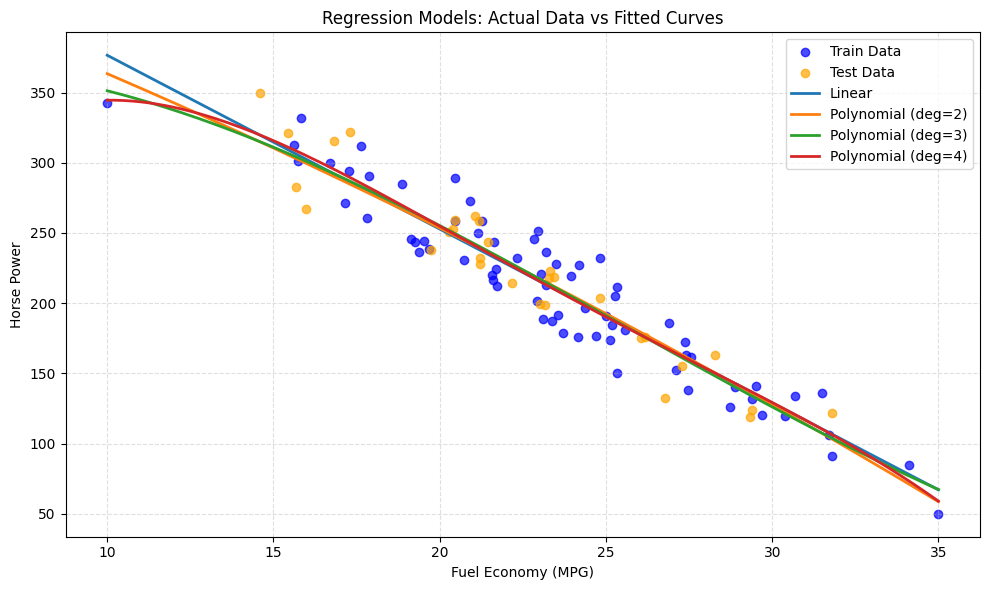

In [17]:
# Create smooth x values for plotting fitted curves
x_plot = np.linspace(X["Fuel Economy (MPG)"].min(), X["Fuel Economy (MPG)"].max(), 200).reshape(-1, 1)

# Get predictions for each model on the smooth x values
y_plot_linear = model_linear.predict(x_plot)
y_plot_poly2 = model_poly2.predict(x_plot)
y_plot_poly3 = model_poly3.predict(x_plot)
y_plot_poly4 = model_poly4.predict(x_plot)

# Plot
plt.figure(figsize=(10, 6))

# Scatter plot of actual data
plt.scatter(X_train, y_train, alpha=0.7, label="Train Data", color="blue")
plt.scatter(X_test, y_test, alpha=0.7, label="Test Data", color="orange")

# Plot fitted curves
plt.plot(x_plot, y_plot_linear, label="Linear", linewidth=2)
plt.plot(x_plot, y_plot_poly2, label="Polynomial (deg=2)", linewidth=2)
plt.plot(x_plot, y_plot_poly3, label="Polynomial (deg=3)", linewidth=2)
plt.plot(x_plot, y_plot_poly4, label="Polynomial (deg=4)", linewidth=2)

plt.xlabel("Fuel Economy (MPG)")
plt.ylabel("Horse Power")
plt.title("Regression Models: Actual Data vs Fitted Curves")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 1.5 Discussion and Interpretation

- ### Which model performs best on the test set?

**Polynomial Regression (degree=4)** performs best with the highest Test R² (0.9139) and lowest Test MSE (313.80).

- ### Does increasing polynomial degree always improve performance?

**No.** While Train R² always increases with higher degree, Test R² does not:
- Linear → Poly(2): Test R² **decreased** from 0.9126 to 0.9091
- Poly(2) → Poly(3): Test R² increased back to 0.9126
- Poly(3) → Poly(4): Test R² improved to 0.9139

This shows that more complexity can hurt generalization if it fits noise rather than the true pattern.

- ### Why does Polynomial (degree=2) perform worse than Linear?

**Two reasons:**
1. **Mild overfitting:** The quadratic term fits training noise (Train R² improved but Test R² decreased)
2. **Nearly linear relationship:** The HP vs MPG relationship is predominantly linear — adding unnecessary polynomial terms introduces noise

### Summary

| Model | Test R² | Test MSE |
|-------|---------|----------|
| Linear | 0.9126 | 318.56 |
| Poly (deg=2) | 0.9091 | 331.11 |
| Poly (deg=3) | 0.9126 | 318.40 |
| **Poly (deg=4)** | **0.9139** | **313.80** |

**Key Takeaway:** All models perform well (R² > 0.90). Polynomial (degree=4) is technically best, but the improvement over Linear Regression is marginal (~0.5%). For simplicity and interpretability, Linear Regression is the reasonable choice to model this data.